In [6]:
import numpy as np
import pandas as pd
import matplotlib as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn .metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

##### 感知机模型

In [8]:
def train_perceptron(X, y, alpha, epoch=1000):
    n_samples, n_features = X.shape # 获取样本数和特征数
    weights = np.zeros(n_features) # 初始化权重
    bias = 0 # 初始化偏置
    for _ in range(epoch):
        misclassified = 0
        for idx, x_i in enumerate(X): # 遍历每一个点
            y_i = np.dot(x_i, weights) + bias
            y_predicted = 1 if y_i >= 0 else -1
            if y[idx] != y_predicted: # 如果点被误分类，则更新权重和偏置import locale
                weights += alpha * y[idx] * x_i
                bias += alpha * y[idx]     
                misclassified += 1
        if misclassified == 0:
            break
    return weights, bias    

* 损失函数是误分类的样本数，不是全部样本数，因此在每一轮中，误分类的样本数为0时，停止迭代
* 但是大部分情况下，误分类的样本数不为0，因此在每一轮迭代中，遍历每一个点，如果点被误分类，则更新权重和偏置
* 使用的是真实标签，而不是预测值，原理是在梯度下降中，基于是真实标签，而不是预测值


In [9]:
X = np.random.randn(100, 2) * 2
y = np.where(X[:, 0] + X[:, 1] > 0, 1, -1)  # 创建一个线性可分的数据集

In [10]:
weights, bias = train_perceptron(X, y, alpha=0.05)

In [11]:
def predict(X, weights, bias):
    y_i = np.dot(X, weights) + bias
    return np.where(y_i >= 0, 1, -1)
predictions = predict(X, weights, bias)

In [12]:
print("权重:", weights)
print("偏置:", bias)
print("预测结果:", predictions)
print("准确率:", accuracy_score(y, predictions))

权重: [0.33663377 0.29553918]
偏置: 0.0
预测结果: [ 1  1 -1 -1 -1  1  1 -1 -1 -1 -1  1  1  1 -1 -1 -1  1 -1  1  1 -1 -1  1
 -1  1  1 -1 -1  1 -1  1  1 -1  1 -1 -1 -1  1 -1  1  1 -1 -1 -1 -1 -1 -1
  1 -1  1  1 -1  1 -1  1  1 -1 -1 -1 -1 -1 -1 -1  1  1 -1  1  1 -1  1  1
 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1  1  1  1  1 -1 -1  1  1  1  1 -1  1
 -1  1 -1  1]
准确率: 1.0


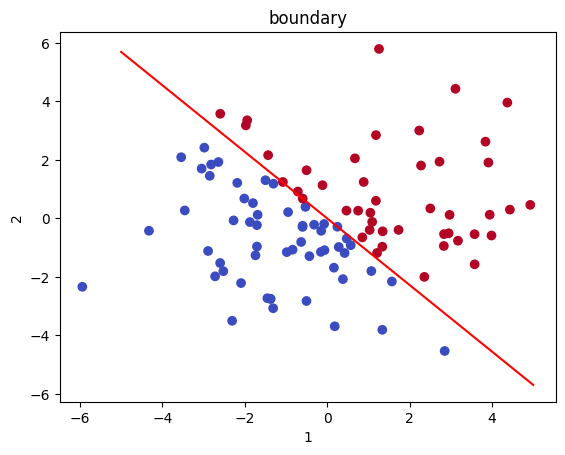

In [13]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
x_points = np.linspace(-5, 5, 400)
y_points = -(weights[0] * x_points + bias) / weights[1]
plt.plot(x_points, y_points, label='Decision Boundary', color='red')
plt.xlabel('1')
plt.ylabel('2')
plt.title('boundary')
plt.show()

##### 用sklearn实现感知机

In [14]:
#用sklearn实现感知机
from sklearn.linear_model import Perceptron
clf = Perceptron(alpha=0.05, max_iter=1000)
clf.fit(X, y)
print("权重:", clf.coef_)
print("偏置:", clf.intercept_)
print("准确率:", clf.score(X, y))

权重: [[7.71686182 7.44090712]]
偏置: [0.]
准确率: 1.0


##### 逻辑回归

In [15]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_logistic_regression(X, y, learning_rate=0.01, epochs=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    
    for _ in range(epochs):
        # 计算预测值
        z = np.dot(X, weights) + bias
        y_pred = sigmoid(z)
        
        # 计算梯度
        dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
        db = (1/n_samples) * np.sum(y_pred - y)
        
        # 更新参数
        weights -= learning_rate * dw
        bias -= learning_rate * db
        
    return weights, bias

def predict_logistic(X, weights, bias):
    z = np.dot(X, weights) + bias
    y_pred = sigmoid(z)
    return np.where(y_pred >= 0.5, 1, -1)

In [16]:
weights, bias = train_logistic_regression(X, y)
predictions = predict_logistic(X, weights, bias)
print("准确率:", accuracy_score(y, predictions))

准确率: 0.91


In [18]:
# 创建网格点
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1 
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))

# 预测
Z = predict_logistic(np.c_[xx.ravel(), yy.ravel()], weights, bias)
Z = Z.reshape(xx.shape)

# 绘图
px.scatter(x=X[:, 0], y=X[:, 1], color=y, 
          title='逻辑回归决策边界',
          labels={'x':'特征1', 'y':'特征2'}).show()


##### sklearn实现


In [19]:
# 使用sklearn实现逻辑回归
from sklearn.linear_model import LogisticRegression

# 训练模型
clf = LogisticRegression()
clf.fit(X, y)

# 预测
predictions = clf.predict(X)
print("sklearn逻辑回归准确率:", accuracy_score(y, predictions))

# 绘制决策边界
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘图
px.scatter(x=X[:, 0], y=X[:, 1], color=y,
          title='sklearn逻辑回归决策边界', 
          labels={'x':'特征1', 'y':'特征2'}).show()


sklearn逻辑回归准确率: 0.99
